In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor  
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [2]:
# Read preprocessed data
d_train = pd.read_csv("MCD_train_data.csv")
d_validation = pd.read_csv("MCD_validation_data.csv")

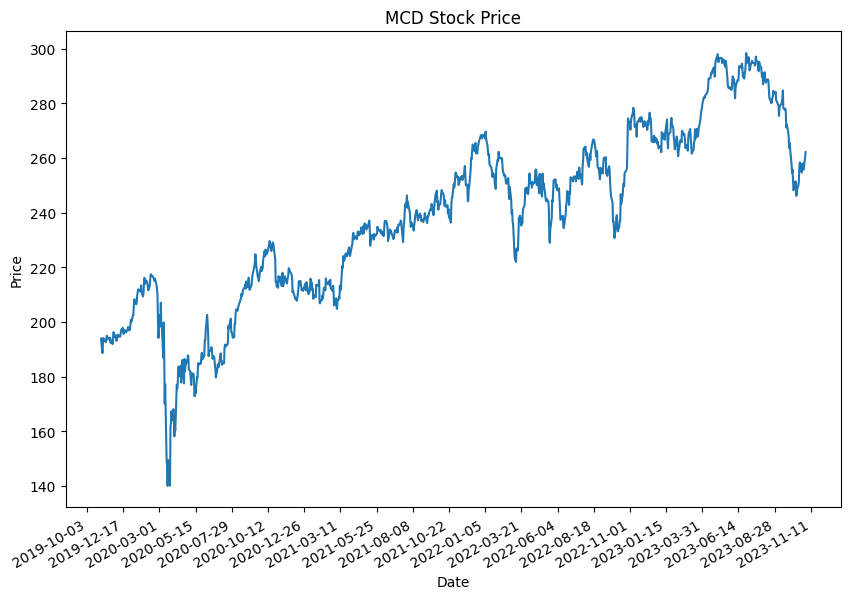

In [ ]:
#visualise training data
d_train["Date"] = pd.to_datetime(d_train["Date"])

plt.figure(figsize=(10,7))
plt.plot(d_train["Date"], d_train["Close"])
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=75))
plt.gcf().autofmt_xdate()
plt.xlabel("Date")
plt.title("MCD Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
#set up train and validation variable
X_train = d_train[["High", "Low", "Open", "Volume"]]
y_train = d_train["Close"]
X_val = d_validation[["High", "Low", "Open", "Volume"]]
y_val = d_validation["Close"]

#scaling
scaling_X = MinMaxScaler()
X_train_scaled = scaling_X.fit_transform(X_train)
X_val_scaled = scaling_X.transform(X_val)
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(y_train.shape)
print(y_val.shape)

(1006, 4)
(126, 4)
(1006,)
(126,)


In [ ]:
#build model and save it
ran_for = RandomForestRegressor(n_estimators=100)
ran_for.fit(X_train_scaled, y_train)
joblib.dump(ran_for, "Saved_Random_Model.pkl")

['Saved_Random_Model.pkl']

In [ ]:
#predict the price using model
y_pred = ran_for.predict(X_val_scaled)

pva = pd.DataFrame(y_val.values, columns=["Actual"], index=d_validation["Date"][:])
pva["Predicted"] = y_pred
pva.index = pd.to_datetime(pva.index)
pva.index.name = "Date"
pva

,Actual,Predicted
Date,,
2023-11-01,261.970001,261.335004
2023-11-02,266.850006,266.144399
2023-11-03,267.869995,267.260999
2023-11-06,268.910004,268.085902
2023-11-07,268.670013,268.780898
...,...,...
2024-04-26,273.089996,272.643294
2024-04-29,273.549988,273.786299
2024-04-30,273.040009,271.017297


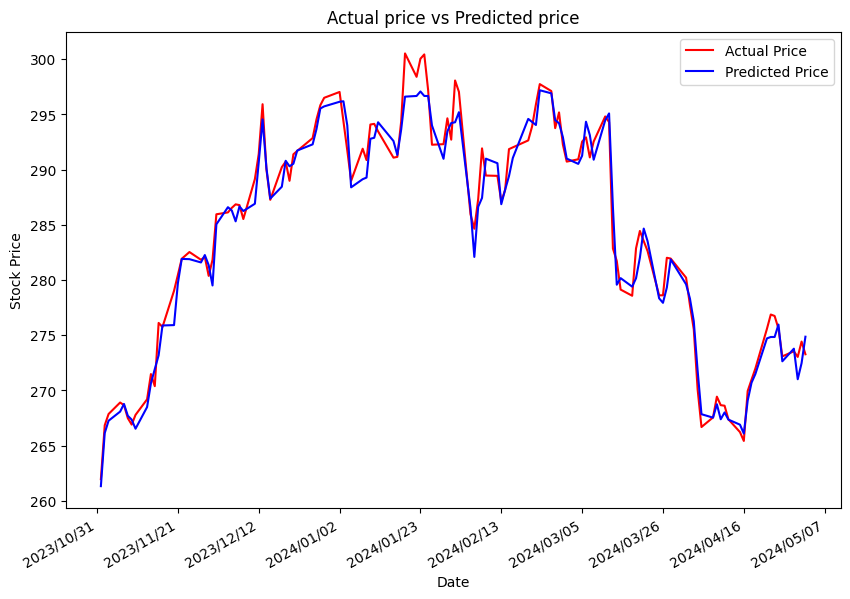

In [ ]:
#Visualize the predicted price
plt.figure(figsize=(10,7))
plt.plot(pva.index, pva["Actual"], label="Actual Price", color="red")
plt.plot(pva.index, pva["Predicted"], label="Predicted Price", color="blue")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=21))
plt.gcf().autofmt_xdate()
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Actual price vs Predicted price")
plt.legend()
plt.show()

In [8]:
# Performance metrics
MSE = mean_squared_error(y_val, y_pred)
MAE = mean_absolute_error(y_val, y_pred)
r_square = r2_score(y_val, y_pred)
print(f"Mean Square Error = {MSE}")
print(f"Mean Absolute Error = {MAE}")
print(f"R-squared value = {r_square}")

Mean Square Error = 2.207179139282014
Mean Absolute Error = 1.1506287589905757
R-squared value = 0.9781770069767081
